# Cliente externo de la API Reference CNN

Este notebook no carga TensorFlow ni accede al modelo serializado. Se comunica exclusivamente por HTTP con la API Flask y envía un espectro sintético para comprobar el flujo completo de clasificación.

Primero ejecuta el notebook del servidor y mantenlo abierto. Si ambos notebooks se ejecutan en el mismo equipo, conserva `http://127.0.0.1:8080`.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

API_URL = "http://127.0.0.1:8081"
REQUEST_TIMEOUT_SECONDS = 30
print("API objetivo:", API_URL)

API objetivo: http://127.0.0.1:8081


## 1. Comprobar la conexión

La API informa el intervalo Raman exacto utilizado por el modelo. Así, el cliente puede construir una entrada que cubra completamente la rejilla sin conocer detalles internos del archivo serializado.

In [2]:
try:
    health_response = requests.get(f"{API_URL}/health", timeout=REQUEST_TIMEOUT_SECONDS)
    health_response.raise_for_status()
except requests.RequestException as exc:
    raise RuntimeError(
        "No fue posible conectar con la API. Comprueba que el notebook servidor siga activo."
    ) from exc

health = health_response.json()
display(pd.DataFrame([health]).T.rename(columns={0: "value"}))

,value
input_points,512
n_classes,255
raman_lower_cm-1,180.709
raman_upper_cm-1,1236.155029
selected_seed,123
service,reference-cnn-raman
status,ok


## 2. Crear un espectro sintético de prueba

La señal combina varios picos gaussianos, una línea base suave y ruido reproducible. Su finalidad es técnica: verificar el transporte, el preprocesamiento y la respuesta del modelo. **No corresponde a un mineral certificado y no debe utilizarse para medir exactitud científica.**

In [3]:
rng = np.random.default_rng(2026)
lower = float(health["raman_lower_cm-1"])
upper = float(health["raman_upper_cm-1"])
raman_shift = np.linspace(lower, upper, 700, dtype=np.float64)

def gaussian_peak(x, center, width, amplitude):
    return amplitude * np.exp(-0.5 * ((x - center) / width) ** 2)

span = upper - lower
intensity = 0.035 + 0.012 * (raman_shift - lower) / span
synthetic_peaks = [
    (lower + 0.16 * span, 8.0, 0.42),
    (lower + 0.31 * span, 11.0, 1.00),
    (lower + 0.49 * span, 7.0, 0.58),
    (lower + 0.68 * span, 15.0, 0.73),
    (lower + 0.86 * span, 10.0, 0.36),
]
for center, width, amplitude in synthetic_peaks:
    intensity += gaussian_peak(raman_shift, center, width, amplitude)
intensity += rng.normal(0.0, 0.006, size=raman_shift.size)
intensity = np.clip(intensity, 0.0, None)

test_spectrum = pd.DataFrame({
    "raman_shift_cm-1": raman_shift,
    "intensity": intensity,
})
display(test_spectrum.head())
print(f"Espectro generado: {len(test_spectrum)} mediciones entre {lower:.2f} y {upper:.2f} cm⁻¹")

,raman_shift_cm-1,intensity
0,180.709000,0.030241
1,182.218937,0.036461
2,183.728874,0.023656
3,185.238811,0.043426
4,186.748748,0.038898


Espectro generado: 700 mediciones entre 180.71 y 1236.16 cm⁻¹


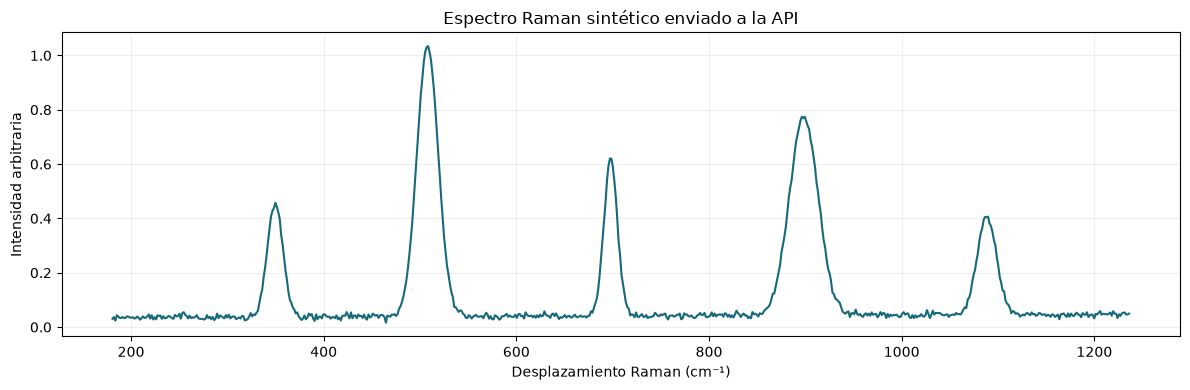

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(raman_shift, intensity, color="#16697A", linewidth=1.5)
ax.set_title("Espectro Raman sintético enviado a la API")
ax.set_xlabel("Desplazamiento Raman (cm⁻¹)")
ax.set_ylabel("Intensidad arbitraria")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 3. Solicitar la clasificación

El cliente envía las mediciones originales. La interpolación a 512 puntos y la normalización ocurren dentro del servidor, evitando que dos clientes apliquen reglas diferentes.

In [5]:
payload = {
    "raman_shift_cm-1": raman_shift.tolist(),
    "intensity": intensity.tolist(),
    "top_k": 5,
}

try:
    prediction_response = requests.post(
        f"{API_URL}/predict", json=payload, timeout=REQUEST_TIMEOUT_SECONDS
    )
    prediction_response.raise_for_status()
except requests.HTTPError as exc:
    try:
        server_error = prediction_response.json()
    except ValueError:
        server_error = prediction_response.text
    raise RuntimeError(f"La API rechazó la petición: {server_error}") from exc
except requests.RequestException as exc:
    raise RuntimeError("La petición a la API no pudo completarse.") from exc

prediction = prediction_response.json()
print("Clase propuesta:", prediction["predicted_class"])
print(f"Confianza softmax: {prediction['confidence']:.2%}")
print("Forma procesada por la API:", prediction["processed_shape"])
display(
    pd.DataFrame(prediction["top_k"])
    .set_index("rank")
    .style.format({"probability": "{:.2%}"})
)
print("ADVERTENCIA:", prediction["warning"])

Clase propuesta: Volborthite
Confianza softmax: 16.41%
Forma procesada por la API: [1, 512, 1]


,class_index,label,probability
rank,,,
1,243,Volborthite,16.41%
2,49,Clinoatacamite,8.23%
3,81,Epidote,2.87%
4,208,Spodumene,2.49%
5,100,Gotzenite,2.30%


ADVERTENCIA: Clasificador de conjunto cerrado: siempre propone una clase conocida. La confianza softmax no demuestra que la muestra pertenezca a RRUFF.


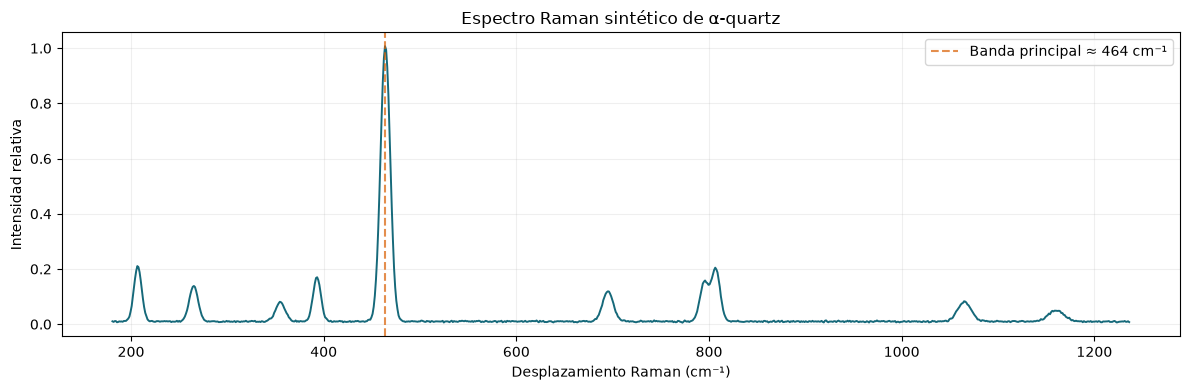

Código HTTP: 200

Mineral esperado: Quartz
Predicción Top-1: Quartz
Confianza Top-1: 75.80%
Forma recibida por la CNN: [1, 512, 1]


,class_index,label,probability,rank
0,182,Quartz,75.80%,1
1,204,Sodalite,3.08%,2
2,243,Volborthite,0.74%,3
3,61,Covellite,0.64%,4
4,152,Muirite,0.39%,5



✓ Quartz apareció en el Top-5, en la posición 1.

Advertencia de la API: Clasificador de conjunto cerrado: siempre propone una clase conocida. La confianza softmax no demuestra que la muestra pertenezca a RRUFF.


In [6]:


# Puerto donde está funcionando la API
API_URL = "http://127.0.0.1:8081"

# Mineral que intentamos representar
MINERAL_ESPERADO = "Quartz"

# 1. Consultar el intervalo Raman requerido por el modelo
health_response = requests.get(
    f"{API_URL}/health",
    timeout=10,
)
health_response.raise_for_status()
health = health_response.json()

lower = float(health["raman_lower_cm-1"])
upper = float(health["raman_upper_cm-1"])

# 2. Eje Raman con 900 mediciones
raman_shift = np.linspace(
    lower,
    upper,
    900,
    dtype=np.float64,
)

# Función para construir cada pico espectral
def gaussian_peak(x, center, width, amplitude):
    return amplitude * np.exp(
        -0.5 * ((x - center) / width) ** 2
    )

# 3. Bandas Raman aproximadas del α-quartz
# (posición cm⁻¹, anchura, intensidad relativa)
quartz_peaks = [
    (207.0, 4.0, 0.20),
    (265.0, 4.5, 0.13),
    (355.0, 5.0, 0.07),
    (393.0, 4.0, 0.16),
    (464.0, 5.0, 1.00),  # banda principal del cuarzo
    (695.0, 5.5, 0.11),
    (795.0, 4.5, 0.14),
    (807.0, 4.5, 0.19),
    (1065.0, 7.0, 0.07),
    (1160.0, 8.0, 0.04),
]

# Línea base suave
intensity = np.full_like(raman_shift, 0.01)

for center, width, amplitude in quartz_peaks:
    if lower <= center <= upper:
        intensity += gaussian_peak(
            raman_shift,
            center,
            width,
            amplitude,
        )

# Ruido pequeño y reproducible
rng = np.random.default_rng(42)
intensity += rng.normal(
    loc=0.0,
    scale=0.0015,
    size=raman_shift.size,
)

intensity = np.clip(intensity, 0.0, None)

# 4. Visualizar el espectro enviado
plt.figure(figsize=(12, 4))
plt.plot(
    raman_shift,
    intensity,
    color="#16697A",
    linewidth=1.4,
)
plt.axvline(
    464,
    color="#D95F02",
    linestyle="--",
    alpha=0.7,
    label="Banda principal ≈ 464 cm⁻¹",
)
plt.title("Espectro Raman sintético de α-quartz")
plt.xlabel("Desplazamiento Raman (cm⁻¹)")
plt.ylabel("Intensidad relativa")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 5. Construir y enviar la petición
payload = {
    "raman_shift_cm-1": raman_shift.tolist(),
    "intensity": intensity.tolist(),
    "top_k": 5,
}

response = requests.post(
    f"{API_URL}/predict",
    json=payload,
    timeout=30,
)

print("Código HTTP:", response.status_code)

if not response.ok:
    print("Error devuelto por la API:")
    print(response.text)
    response.raise_for_status()

result = response.json()

# 6. Mostrar el resultado
ranking = pd.DataFrame(result["top_k"])
ranking["probability"] = ranking["probability"].map(
    lambda value: f"{value:.2%}"
)

print("\nMineral esperado:", MINERAL_ESPERADO)
print("Predicción Top-1:", result["predicted_class"])
print(f"Confianza Top-1: {result['confidence']:.2%}")
print("Forma recibida por la CNN:", result["processed_shape"])

display(ranking)

top5_labels = [
    prediction["label"]
    for prediction in result["top_k"]
]

if MINERAL_ESPERADO in top5_labels:
    position = top5_labels.index(MINERAL_ESPERADO) + 1
    print(
        f"\n✓ Quartz apareció en el Top-5, "
        f"en la posición {position}."
    )
else:
    print(
        "\nQuartz no apareció en el Top-5. "
        "Esto puede ocurrir porque la señal es una aproximación "
        "sintética y no una medición RRUFF real."
    )

print("\nAdvertencia de la API:", result["warning"])

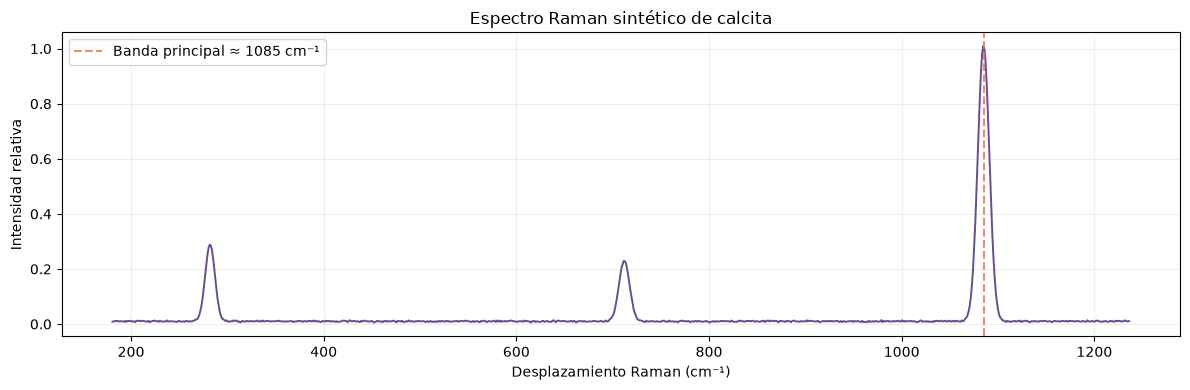

Código HTTP: 200

Mineral esperado: Calcite
Predicción Top-1: Siderite
Confianza Top-1: 82.63%
Forma procesada: [1, 512, 1]


,class_index,label,probability,rank
0,197,Siderite,82.63%,1
1,188,Rosasite,2.48%,2
2,132,Magnesite,0.68%,3
3,124,Lanthanite-(Nd),0.57%,4
4,72,Dolomite,0.49%,5



Calcite no apareció en el Top-5. La señal reproduce sus bandas principales, pero continúa siendo una aproximación sintética y no una medición RRUFF real.

Advertencia: Clasificador de conjunto cerrado: siempre propone una clase conocida. La confianza softmax no demuestra que la muestra pertenezca a RRUFF.


In [7]:
API_URL = "http://127.0.0.1:8081"
MINERAL_ESPERADO = "Calcite"

# Consultar el intervalo Raman requerido
health_response = requests.get(
    f"{API_URL}/health",
    timeout=10,
)
health_response.raise_for_status()
health = health_response.json()

lower = float(health["raman_lower_cm-1"])
upper = float(health["raman_upper_cm-1"])

# Crear el eje Raman
raman_shift = np.linspace(
    lower,
    upper,
    900,
    dtype=np.float64,
)

def gaussian_peak(x, center, width, amplitude):
    return amplitude * np.exp(
        -0.5 * ((x - center) / width) ** 2
    )

# Posición, anchura e intensidad relativa aproximadas
calcite_peaks = [
    (282.0, 5.0, 0.28),
    (712.0, 5.5, 0.22),
    (1085.0, 6.0, 1.00),  # banda principal de la calcita
]

# Línea base suave
intensity = np.full_like(raman_shift, 0.01)

for center, width, amplitude in calcite_peaks:
    if lower <= center <= upper:
        intensity += gaussian_peak(
            raman_shift,
            center,
            width,
            amplitude,
        )

# Ruido pequeño y reproducible
rng = np.random.default_rng(123)
intensity += rng.normal(
    0.0,
    0.0015,
    size=raman_shift.size,
)
intensity = np.clip(intensity, 0.0, None)

# Visualizar el espectro
plt.figure(figsize=(12, 4))
plt.plot(
    raman_shift,
    intensity,
    color="#6A4C93",
    linewidth=1.4,
)
plt.axvline(
    1085,
    color="#E76F51",
    linestyle="--",
    alpha=0.8,
    label="Banda principal ≈ 1085 cm⁻¹",
)
plt.title("Espectro Raman sintético de calcita")
plt.xlabel("Desplazamiento Raman (cm⁻¹)")
plt.ylabel("Intensidad relativa")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Enviar petición
payload = {
    "raman_shift_cm-1": raman_shift.tolist(),
    "intensity": intensity.tolist(),
    "top_k": 5,
}

response = requests.post(
    f"{API_URL}/predict",
    json=payload,
    timeout=30,
)

print("Código HTTP:", response.status_code)

if not response.ok:
    print(response.text)
    response.raise_for_status()

result = response.json()

# Mostrar resultados
ranking = pd.DataFrame(result["top_k"])
ranking["probability"] = ranking["probability"].map(
    lambda value: f"{value:.2%}"
)

print("\nMineral esperado:", MINERAL_ESPERADO)
print("Predicción Top-1:", result["predicted_class"])
print(f"Confianza Top-1: {result['confidence']:.2%}")
print("Forma procesada:", result["processed_shape"])

display(ranking)

top5_labels = [
    prediction["label"]
    for prediction in result["top_k"]
]

if MINERAL_ESPERADO in top5_labels:
    position = top5_labels.index(MINERAL_ESPERADO) + 1
    print(
        f"\n✓ Calcite apareció en el Top-5, "
        f"en la posición {position}."
    )
else:
    print(
        "\nCalcite no apareció en el Top-5. "
        "La señal reproduce sus bandas principales, pero continúa "
        "siendo una aproximación sintética y no una medición RRUFF real."
    )

print("\nAdvertencia:", result["warning"])


## Interpretación correcta

Una respuesta satisfactoria confirma que el prototipo puede recibir un espectro de longitud variable, transformarlo al formato `(1, 512, 1)` y devolver probabilidades ordenadas. No confirma que el espectro sintético pertenezca al mineral propuesto: el modelo actual es un clasificador de conjunto cerrado y todavía no dispone de detección de muestras desconocidas o fuera de distribución.